# Refitting the ME1 scaling constants

A Python replacement for `Combined_Pathway_Optimizer.m` / `Combined_Pathway_Handler.m`.
It fits the same 18 scaling parameters, to the same three datasets, with the same
objective -- but only the **optimization** was translated.

The model itself is not re-implemented. `Reactions/EC_FAS_ME1/C20+unsat+FBinit` was checked
reaction-for-reaction against the MATLAB ODEs -- 588 directed steps, every rate constant
equal -- and its YAML already declares all 18 scaling parameters, including the composite
expressions `(1/b3)`, `(b1/b2)`, `(f*c2)` and the TesA free-energy terms `1/exp(n*d1+d2)`.
Setting 18 numbers makes the builder recompute every rate constant, which is exactly what
`param_func.m` did in 463 lines of branching.

| | MATLAB | here |
|---|---|---|
| parameterisation | `param_func.m`, 463 lines | 18 values, declared in the reaction YAML |
| conditions | hard-coded `enz_conc_*` vectors | `me1_config.RATE_CONDITIONS` |
| targets | literals inside the objective | CSVs in `data/` |
| bounds | `1e8` sentinels inline | `me1_config.UPPER_BOUNDS` / `LOWER_BOUNDS` |
| which parameters are fitted | a 300-character anonymous function | one list, below |
| solving 7 conditions | a loop | one batched call |

**Read section 2 before trusting a refit.** Two properties of the objective
affect what it converges to.

## 0. Setup

In [1]:
import sys, time
sys.path.insert(0, '.')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import minimize

import me1_config as cfg, me1_model as mm, me1_objective as mo

model = mm.ME1Model()          # builds the network once; ~3 s
data  = mo.load_data()
published = dict(cfg.PUBLISHED)
print(f'{len(model.species)} species, {len(model.params)} parameters')
print(f'scaling parameters: {cfg.PARAM_NAMES}')

318 species, 214 parameters
scaling parameters: ['a1', 'a2', 'a3', 'b1', 'c2', 'c3', 'c1', 'b2', 'b3', 'd1', 'd2', 'e', 'f', 'c4', 'x1', 'x2', 'x3', 'x4']


In [2]:
# What each parameter controls, and its published value.
pd.DataFrame([{'parameter': n, 'published': cfg.PUBLISHED[n],
               'kind': 'additive (in exp)' if n in cfg.ADDITIVE else 'multiplicative',
               'fitted by the MATLAB': n in cfg.MATLAB_FITTED,
               'role': cfg.WHAT_EACH_DOES[n]} for n in cfg.PARAM_NAMES])

,parameter,published,kind,fitted by the MATLAB,role
0,a1,142473.723800,multiplicative,False,"initiation binding (FabD, FabH)"
1,a2,7597.676912,multiplicative,False,"elongation binding (FabF, FabB, and the shared..."
2,a3,4.276690,multiplicative,False,termination binding (TesA)
3,b1,40213.929190,multiplicative,False,"Kd fit, used as (b1/b2) and (b1/b3)"
4,c2,88.885254,multiplicative,False,"elongation kcat (FabG, FabI, FabF, FabA, FabB)"
5,c3,0.005388,multiplicative,False,termination kcat (TesA)
6,c1,4.645635,multiplicative,False,"initiation kcat (FabD, FabH)"
7,b2,0.006678,multiplicative,False,"Kd fit, appears only as (b1/b2)"
8,b3,0.284982,multiplicative,False,"Kd fit, appears as (1/b3) and (b1/b3)"
9,d1,-0.285700,additive (in exp),False,"TesA linear free-energy SLOPE, additive inside..."


## 1. Does the published parameter set reproduce?

One objective evaluation: seven initial rates, one time course, one profile.

In [3]:
t0 = time.time()
ref = mo.evaluate(model, published, data=data)     # first call compiles; ~45 s
print(f'{time.time()-t0:.1f} s')
print(f'obj1 (rates)   = {ref.obj1:10.4f}')
print(f'obj2 (time)    = {ref.obj2:10.4f}')
print(f'obj3 (profile) = {ref.obj3:10.4f}')
print(f'total (product)= {ref.total:10.4g}')

43.6 s
obj1 (rates)   =     1.5732
obj2 (time)    =    52.5739
obj3 (profile) =    19.4361
total (product)=       1608


In [4]:
meas = data[0]['measured_rate_uM_C16_per_min'].to_numpy()
rates = pd.DataFrame({
    'condition': [c['label'] for c in cfg.RATE_CONDITIONS],
    'measured (uM C16/min)': meas,
    'model uM at 150 s': ref.model_rates,
    'model uM/min': ref.model_rates / 2.5,
})
rates['ratio (uM/min)'] = rates['model uM/min'] / rates['measured (uM C16/min)']
rates.round(3)

,condition,measured (uM C16/min),model uM at 150 s,model uM/min,ratio (uM/min)
0,reference,4.655,13.149,5.260,1.130
1,no FabH,2.418,7.519,3.008,1.244
2,"no FabH, no FabF",1.796,5.281,2.112,1.176
3,"no FabH, no FabB",2.976,6.614,2.645,0.889
4,"no FabH, no AcCoA",2.917,5.353,2.141,0.734
5,"no FabH, no FabF, no AcCoA",0.893,2.336,0.934,1.046
6,"no FabH, no FabB, no AcCoA",2.429,6.614,2.645,1.089


Every condition produces product, including the six with **FabH removed**. That is the
contribution of the `+FBinit` reaction set: without the FabB/FabF decarboxylation route,
the model returns exactly zero for all of them and cannot fit this dataset at all.

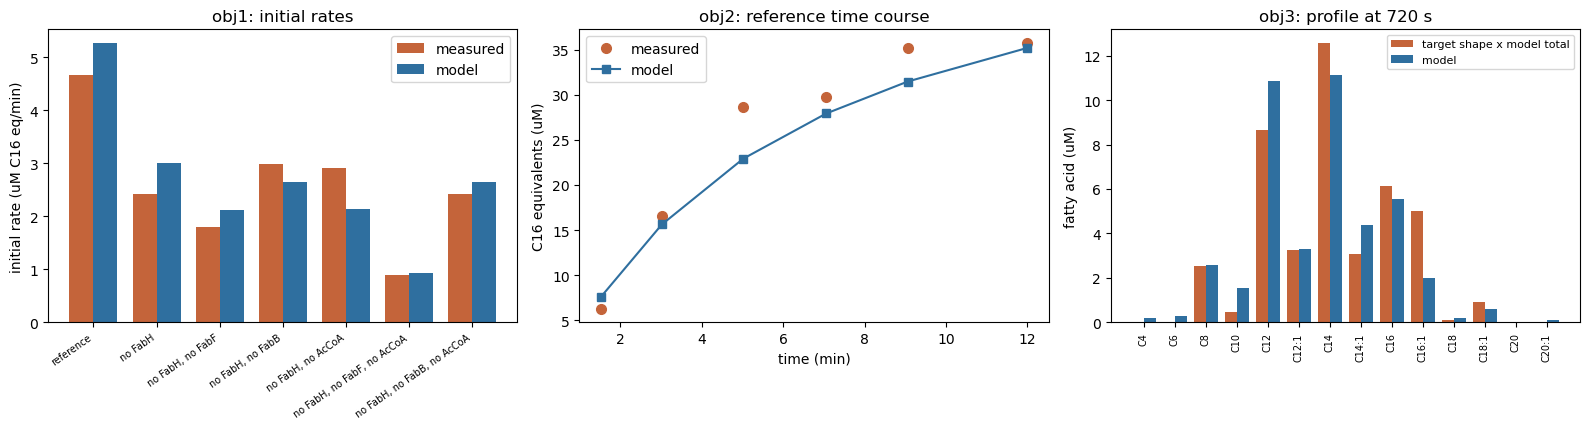

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
x = np.arange(len(rates)); w = 0.38
ax.bar(x - w/2, meas, w, label='measured', color='#c4643a')
ax.bar(x + w/2, ref.model_rates/2.5, w, label='model', color='#2f6f9f')
ax.set_xticks(x); ax.set_xticklabels(rates['condition'], rotation=35, ha='right', fontsize=7)
ax.set_ylabel('initial rate (uM C16 eq/min)'); ax.set_title('obj1: initial rates'); ax.legend()

ax = axes[1]
tc = data[1]
ax.plot(tc['time_min'], tc['c16_equivalents_uM'], 'o', color='#c4643a', ms=7, label='measured')
ax.plot(tc['time_min'], ref.model_timecourse, 's-', color='#2f6f9f', label='model')
ax.set_xlabel('time (min)'); ax.set_ylabel('C16 equivalents (uM)')
ax.set_title('obj2: reference time course'); ax.legend()

ax = axes[2]
prof = data[2]
labels = [f"C{r.chain}{':1' if r.unsaturated else ''}" for r in prof.itertuples()]
target = ref.model_profile.sum() * prof['mole_fraction'].to_numpy()
x = np.arange(len(labels))
ax.bar(x - w/2, target, w, label='target shape x model total', color='#c4643a')
ax.bar(x + w/2, ref.model_profile, w, label='model', color='#2f6f9f')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('fatty acid (uM)'); ax.set_title('obj3: profile at 720 s'); ax.legend(fontsize=8)

fig.tight_layout(); plt.show()

## 2. Two properties of the objective

Neither is a defect; both affect where the optimizer goes.

### 2a. obj3 cannot see total production

It compares the model profile against `total_FA * fractions`, where `total_FA` is the
model's **own** total. Scale every species by the same factor and obj3 is unchanged, so it
constrains the shape of the distribution and nothing else. Titre is constrained only by
obj1 and obj2.

In [6]:
scaled = ref.model_profile * 3.0          # triple every species
t1 = np.sum((ref.model_profile - ref.model_profile.sum()*prof['mole_fraction'].to_numpy())**2)
t3 = np.sum((scaled - scaled.sum()*prof['mole_fraction'].to_numpy())**2)
print(f'obj3 at the model profile      : {t1:.4f}')
print(f'obj3 with everything tripled   : {t3:.4f}   ({t3/t1:.1f}x -- it scales, it does not stay equal)')
print('\nIt is not invariant, but it is quadratic in the total, so a bigger model is')
print('penalised for being bigger even when the SHAPE is identical. Worth knowing.')

obj3 at the model profile      : 19.4361
obj3 with everything tripled   : 174.9253   (9.0x -- it scales, it does not stay equal)

It is not invariant, but it is quadratic in the total, so a bigger model is
penalised for being bigger even when the SHAPE is identical. Worth knowing.


### 2b. The three terms are multiplied

`total_obj = obj1 * obj2 * obj3`. A near-zero in any single term collapses the product
regardless of the other two, and the relative weighting is whatever the terms happen to be
in their own units. `combine='sum'` and `'log_sum'` are available; neither reproduces the
published fit, so switch only deliberately.

In [7]:
for how in ('product', 'sum', 'log_sum'):
    r = mo.evaluate(model, published, data=data, combine=how)
    print(f'{how:9s} total = {r.total:12.4g}')

product   total =         1608


sum       total =        73.58


log_sum   total =        7.382


## 2c. Held-out validation

Figure S1(D) evaluates the model against initial rates it was **not** fitted on
(Ruppe et al. 2020). Six conditions, all on the reference background.

Only the measurements are plotted from that figure; its own Model column comes from the
300-run initial-concentration study, not a single deterministic solve, so the model bars
here are computed fresh.

Substrates stay at 0.5 mM malonyl-CoA / 0.5 mM acetyl-CoA / 1 mM NADPH / 1 mM NADH here as
everywhere else. That composition represents the in vivo cytosol, which is what lets one
parameter set serve both the in vitro datasets (A, C) and the in vivo profile (B); enzyme
level is the only thing that varies between conditions.

In [8]:
held = pd.read_csv(cfg.DATA / 'heldout_initial_rates.csv')
held['model_uM_per_min'] = model.initial_rates_c16(published, cfg.HELDOUT_CONDITIONS) / 2.5
held['ratio'] = held['model_uM_per_min'] / held['measured_rate_uM_C16_per_min']
held.round(3)

,condition,measured_rate_uM_C16_per_min,standard_error,source,model_uM_per_min,ratio
0,reference,3.928,0.134,Figure S1 New Initial Rates 4B.dgraph,5.260,1.339
1,30 uM FabH,9.988,0.432,Figure S1 New Initial Rates 4B.dgraph,1.343,0.134
2,10 uM FabF,2.269,0.251,Figure S1 New Initial Rates 4B.dgraph,4.803,2.117
3,10 uM FabI,5.375,0.345,Figure S1 New Initial Rates 4B.dgraph,5.864,1.091
4,no FabZ,0.841,0.089,Figure S1 New Initial Rates 4B.dgraph,0.869,1.033
5,10 uM FabA + no FabZ,2.552,0.131,Figure S1 New Initial Rates 4B.dgraph,4.923,1.929


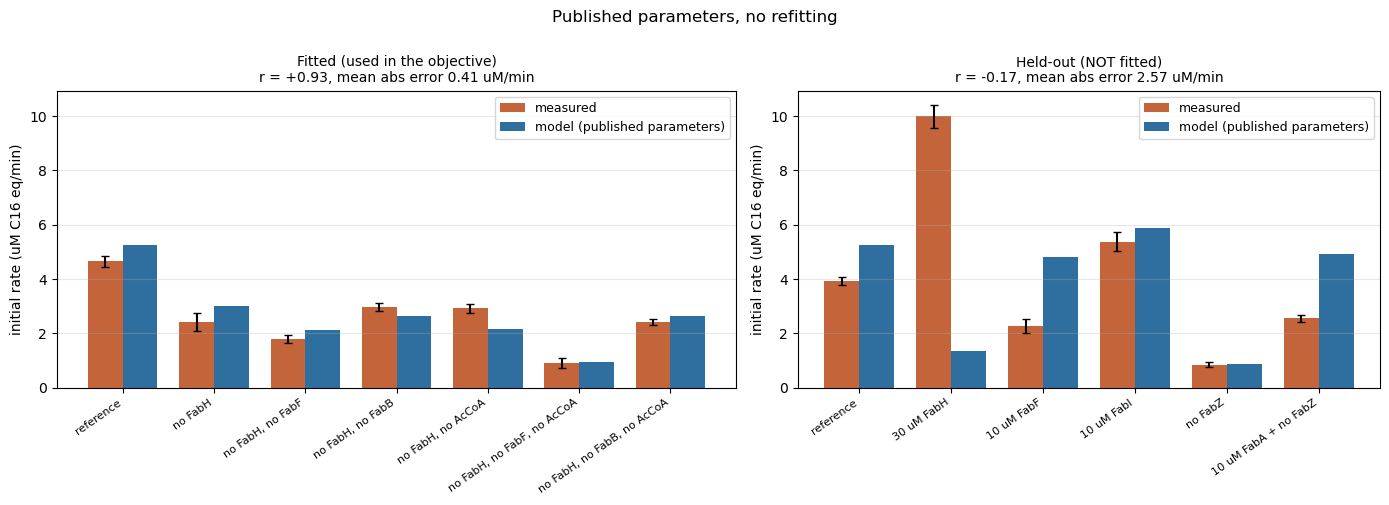

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [7, 6]})
panels = [(meas, data[0]['standard_error'].to_numpy(), ref.model_rates/2.5,
           [c['label'] for c in cfg.RATE_CONDITIONS], 'Fitted (used in the objective)'),
          (held['measured_rate_uM_C16_per_min'].to_numpy(), held['standard_error'].to_numpy(),
           held['model_uM_per_min'].to_numpy(),
           [c['label'] for c in cfg.HELDOUT_CONDITIONS], 'Held-out (NOT fitted)')]
for ax, (m, se, pred, names, title) in zip(axes, panels):
    x = np.arange(len(names)); w = 0.38
    ax.bar(x-w/2, m, w, yerr=se, capsize=3, color='#c4643a', label='measured')
    ax.bar(x+w/2, pred, w, color='#2f6f9f', label='model (published parameters)')
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
    ax.set_ylabel('initial rate (uM C16 eq/min)')
    ax.set_title(f'{title}\nr = {np.corrcoef(m,pred)[0,1]:+.2f}, '
                 f'mean abs error {np.mean(np.abs(pred-m)):.2f} uM/min', fontsize=10)
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
ymax = max(a.get_ylim()[1] for a in axes)
for a in axes: a.set_ylim(0, ymax)
fig.suptitle('Published parameters, no refitting', y=1.0)
fig.tight_layout(); plt.show()

The three misses are the ones the paper reports itself: it *underpredicts* 30 uM FabH and
*overpredicts* 10 uM FabF and 10 uM FabA, and attributes them to the active-ACP fraction,
an underestimated FabF concentration, or an overestimated FabA activity. Reproducing those
discrepancies in the same direction and rough magnitude is the check that this port is
faithful -- the remaining three conditions agree to within 3-9%.

## 2d. What the two FBinit reactions buy

`C20+unsat+FBinit` differs from `C20+unsat` by exactly two reactions -- a decarboxylative
condensation on each of FabB and FabF that releases `C4_BKeAcACP`, i.e. FabH-independent
initiation. Without them the model still forms the activated FabB*/FabF* species but has no
way to release product from them, so that whole route is a dead end.

Scored against all four Figure S1 datasets at the published parameters, no refitting.

In [10]:
base = mm.ME1Model(reactions_dir=cfg.PROJECT / 'Reactions/EC_FAS_ME1/C20+unsat')
t_data = tc['time_min'].to_numpy() * 60.0
times  = np.unique(np.concatenate([t_data, [cfg.ENDPOINT_S]]))

def score(M):
    sol = M.solve(published, M.condition_y0(cfg.RATE_CONDITIONS[0]), times)
    at = {float(t): k for k, t in enumerate(times)}
    return {'fitted':  M.initial_rates_c16(published) / 2.5,
            'heldout': M.initial_rates_c16(published, cfg.HELDOUT_CONDITIONS) / 2.5,
            'curve':   np.array([sol.c16_equivalents[at[float(t)]] for t in t_data]),
            'profile': sol.profile[at[float(cfg.ENDPOINT_S)]],
            'obj':     mo.evaluate(M, published, data=data)}

sets = {'C20+unsat': (base, '#8a6bbf'), 'C20+unsat+FBinit': (model, '#2f6f9f')}
scored = {n: score(M) for n, (M, _) in sets.items()}

held_m = held['measured_rate_uM_C16_per_min'].to_numpy()
pd.DataFrame([{'reaction set': n,
               'A obj1 fitted rates': s['obj'].obj1,
               'B obj3 profile':      s['obj'].obj3,
               'C obj2 time course':  s['obj'].obj2,
               'D held-out mean abs err': float(np.mean(np.abs(s['heldout'] - held_m)))}
              for n, s in scored.items()]).round(3)

,reaction set,A obj1 fitted rates,B obj3 profile,C obj2 time course,D held-out mean abs err
0,C20+unsat,33.374,16.813,74.119,2.406
1,C20+unsat+FBinit,1.573,19.436,52.574,2.567


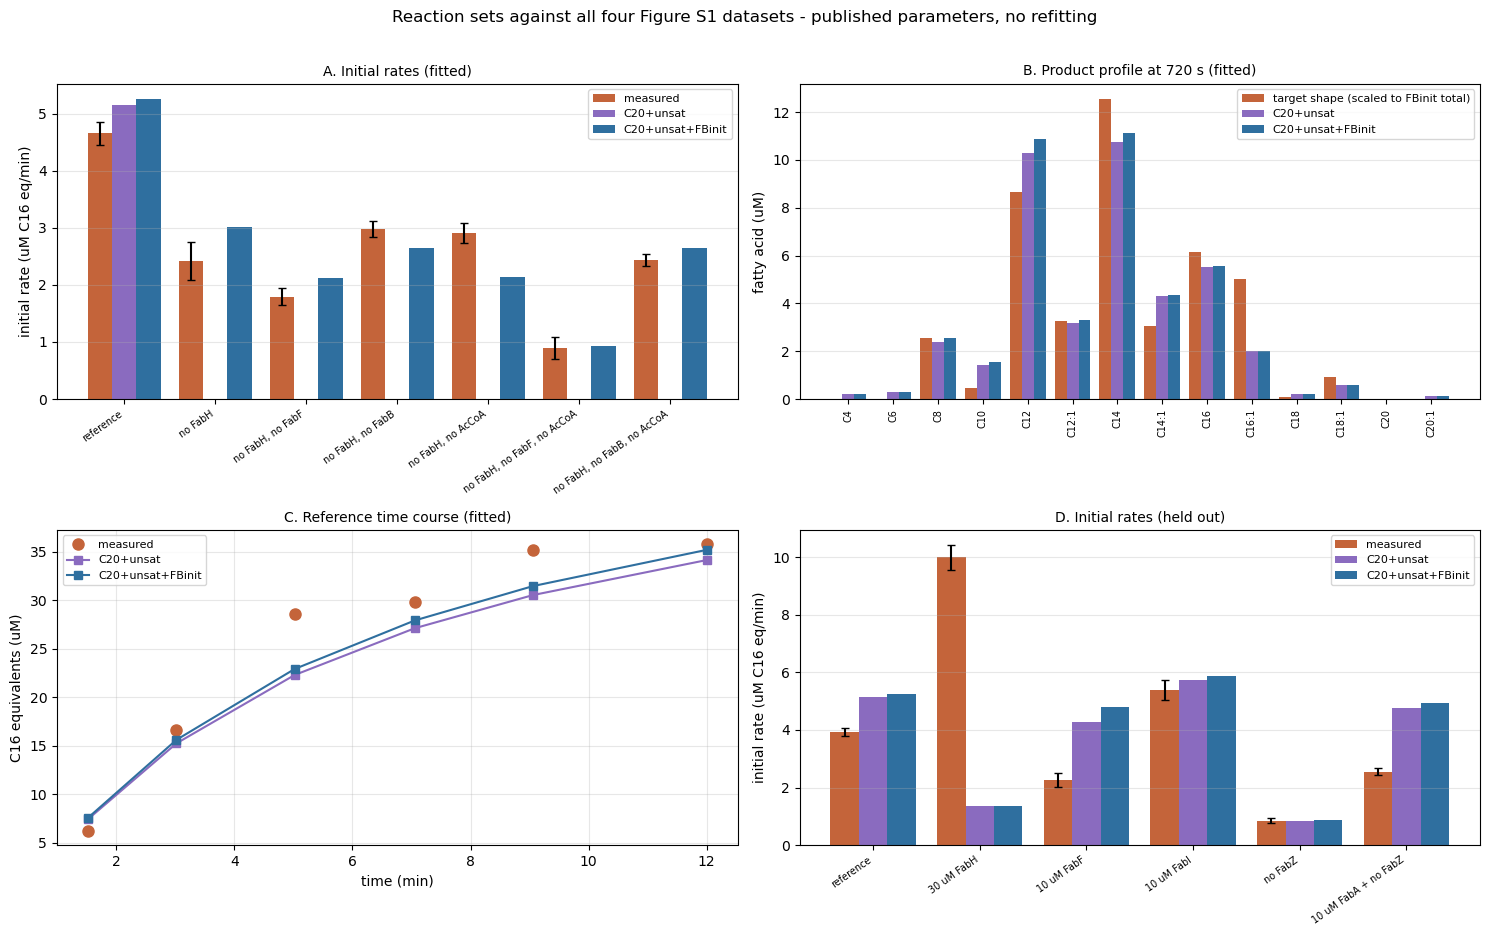

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9.5))
nS = len(sets); w = 0.8 / (nS + 1)

def bars(ax, names, m, se, key, title):
    x = np.arange(len(names))
    ax.bar(x - w, m, w, yerr=se, capsize=3, color='#c4643a', label='measured')
    for i, (n, (_, colour)) in enumerate(sets.items()):
        ax.bar(x + i*w, scored[n][key], w, color=colour, label=n)
    ax.set_xticks(x); ax.set_xticklabels(names, rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('initial rate (uM C16 eq/min)'); ax.set_title(title, fontsize=10)
    ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)

bars(axes[0][0], [c['label'] for c in cfg.RATE_CONDITIONS], meas,
     data[0]['standard_error'].to_numpy(), 'fitted', 'A. Initial rates (fitted)')
bars(axes[1][1], [c['label'] for c in cfg.HELDOUT_CONDITIONS], held_m,
     held['standard_error'].to_numpy(), 'heldout', 'D. Initial rates (held out)')

ax = axes[1][0]
ax.plot(tc['time_min'], tc['c16_equivalents_uM'], 'o', color='#c4643a', ms=8, label='measured')
for n, (_, colour) in sets.items():
    ax.plot(tc['time_min'], scored[n]['curve'], 's-', color=colour, label=n)
ax.set_xlabel('time (min)'); ax.set_ylabel('C16 equivalents (uM)')
ax.set_title('C. Reference time course (fitted)', fontsize=10); ax.grid(alpha=0.3); ax.legend(fontsize=8)

ax = axes[0][1]
x = np.arange(len(labels))
ax.bar(x - w, scored['C20+unsat+FBinit']['profile'].sum() * prof['mole_fraction'].to_numpy(),
       w, color='#c4643a', label='target shape (scaled to FBinit total)')
for i, (n, (_, colour)) in enumerate(sets.items()):
    ax.bar(x + i*w, scored[n]['profile'], w, color=colour, label=n)
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=7)
ax.set_ylabel('fatty acid (uM)'); ax.set_title('B. Product profile at 720 s (fitted)', fontsize=10)
ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)

fig.suptitle('Reaction sets against all four Figure S1 datasets - published parameters, no refitting')
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

**obj1 falls from 33.4 to 1.57 -- a 21x improvement from two reactions.** Without them the
six FabH-free conditions in dataset A produce *exactly zero*, so the base model cannot fit
that dataset at all. The time course also improves (74.1 to 52.6).

Two things do not improve. The profile term is slightly worse (16.8 to 19.4), and the
held-out set is unchanged within noise (2.41 vs 2.57 mean abs error) -- every held-out
condition has FabH present, so the FabH-independent route contributes little there. The
held-out failure is a separate problem from initiation.

## 2e. The 2025 rates, and why initiation was removed

A later held-out set asks the question the FBinit reactions exist to answer: **does the
pathway still run without FabH?**

The measurement says essentially no -- 0.43 +/- 0.43 uM C16 eq/min against a reference of
10.33, i.e. 4% of reference and statistically indistinguishable from zero. The older
kinetics set had put the same condition at 2.42, which is what motivated adding
FabH-independent initiation in the first place.

Note the experiment ran at 100 uM acetyl-CoA while the model is solved at its standard
500 uM basis, and the 2025 reference is 2x the older one (10.33 vs 4.66). Absolute
agreement is therefore poor for both reaction sets; the discriminating comparison is the
pattern **relative to reference**.

In [12]:
h25 = pd.read_csv(cfg.DATA / 'heldout_2025_initial_rates.csv')
# base and model were built in 2d; only the conditions change.
h25['C20+unsat']        = base.initial_rates_c16(published, cfg.HELDOUT_2025_CONDITIONS) / 2.5
h25['C20+unsat+FBinit'] = model.initial_rates_c16(published, cfg.HELDOUT_2025_CONDITIONS) / 2.5
m25 = h25['measured_rate_uM_C16_per_min'].to_numpy()
for col in ('measured_rate_uM_C16_per_min', 'C20+unsat', 'C20+unsat+FBinit'):
    h25[col + ' /ref'] = h25[col] / h25[col].iloc[0]
h25[['condition', 'measured_rate_uM_C16_per_min', 'standard_error',
     'C20+unsat', 'C20+unsat+FBinit',
     'measured_rate_uM_C16_per_min /ref', 'C20+unsat /ref',
     'C20+unsat+FBinit /ref']].round(3)

,condition,measured_rate_uM_C16_per_min,standard_error,C20+unsat,C20+unsat+FBinit,measured_rate_uM_C16_per_min /ref,C20+unsat /ref,C20+unsat+FBinit /ref
0,reference,10.334,0.356,5.146,5.260,1.000,1.000,1.000
1,no FabH,0.429,0.429,-0.000,3.008,0.042,-0.000,0.572
2,no AcCoA,6.043,0.355,4.123,4.187,0.585,0.801,0.796
3,"no AcCoA, no FabH",1.620,1.041,-0.000,2.141,0.157,-0.000,0.407


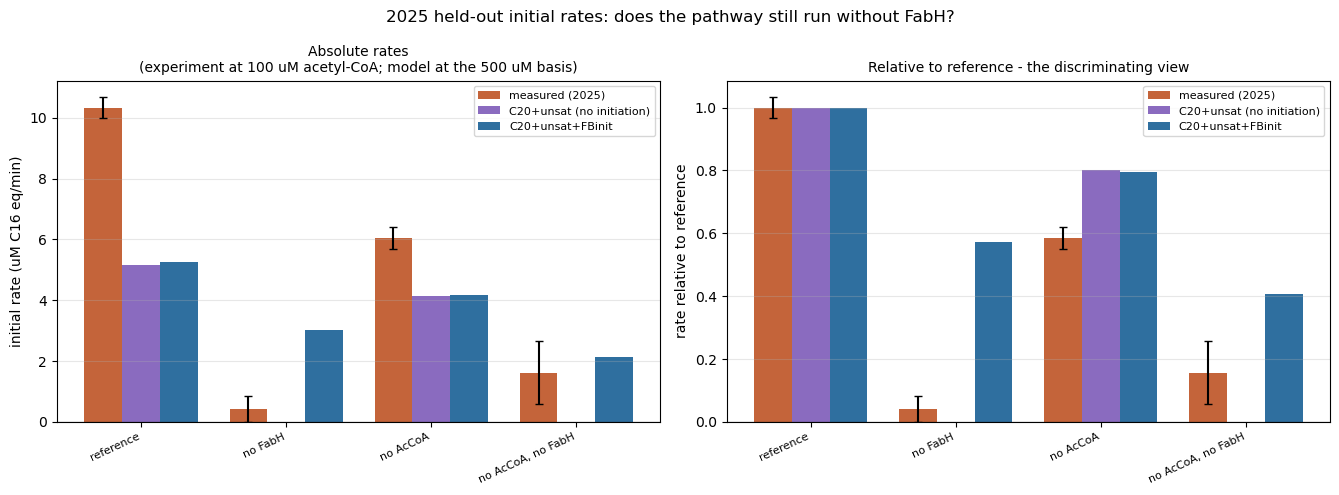

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
x = np.arange(len(h25)); w = 0.26
se25 = h25['standard_error'].to_numpy()
for ax, scale, title in (
        (axes[0], 1.0, 'Absolute rates\n(experiment at 100 uM acetyl-CoA; model at the 500 uM basis)'),
        (axes[1], None, 'Relative to reference - the discriminating view')):
    norm = (lambda v: np.asarray(v)) if scale else (lambda v: np.asarray(v)/np.asarray(v)[0])
    err  = se25 if scale else se25 / m25[0]
    ax.bar(x-w, norm(m25), w, yerr=err, capsize=3, color='#c4643a', label='measured (2025)')
    ax.bar(x,   norm(h25['C20+unsat']), w, color='#8a6bbf', label='C20+unsat (no initiation)')
    ax.bar(x+w, norm(h25['C20+unsat+FBinit']), w, color='#2f6f9f', label='C20+unsat+FBinit')
    ax.set_xticks(x); ax.set_xticklabels(h25['condition'], rotation=25, ha='right', fontsize=8)
    ax.axhline(0, color='k', lw=0.8); ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
axes[0].set_ylabel('initial rate (uM C16 eq/min)'); axes[1].set_ylabel('rate relative to reference')
fig.suptitle('2025 held-out initial rates: does the pathway still run without FabH?')
fig.tight_layout(); plt.show()

**Removing FabH, as a fraction of reference:** measured keeps **4%**, `C20+unsat` keeps
**0%**, `C20+unsat+FBinit` keeps **57%**. With acetyl-CoA also absent: measured 16%,
`C20+unsat` 0%, FBinit 41%.

FBinit is qualitatively wrong on exactly the behaviour it was added to produce -- it keeps
the pathway running at more than half rate with no FabH, where the experiment sees almost
nothing. That is the evidence for removing the initiation reactions.

Worth holding both datasets in view: section 2d showed FBinit improving obj1 21-fold
*because* the older kinetics set has the FabH-free conditions producing real rates
(0.89-2.98). The two datasets disagree about the same chemistry, and the 2025 set is the
one with a near-zero measurement and an error bar to match. This is a data-reconciliation
question, not only a modelling one.

## 3. Refit

Set which parameters to vary and the budget, then run. `MATLAB_FITTED` is the five the
original optimizer varied (`f`, `x1`, `x2`, `x3`, `x4`); everything else was pinned inside
the anonymous `fitfunc`.

**Cost.** One objective evaluation is about 20-25 s (eight stiff solves of a 318-species
system). Nelder-Mead on five parameters typically wants a few hundred, so a full refit is a
background job of 1-3 hours, not an interactive cell. `MAX_EVALS` below is set low so the
notebook runs end to end; raise it for a real fit.

Parameters are fitted in **log10** space (except `d1`/`d2`, which are additive). The
published values span 0.0054 to 142,474, and Nelder-Mead steps in absolute units, so a
simplex able to move `c3` cannot move `a1` at all. The MATLAB did not do this.

In [14]:
FITTED    = cfg.MATLAB_FITTED      # or e.g. ['f','x1','x2','x3','x4','c2','c3']
MAX_EVALS = 25                     # raise to ~1000 for a real refit
COMBINE   = 'product'

f  = mo.make_scalar_objective(model, FITTED, published, data=data, combine=COMBINE)
x0 = f.pack(published)
print('fitting:', FITTED)
print('start  :', {n: round(published[n], 6) for n in FITTED})
print(f'budget : {MAX_EVALS} evaluations (~{MAX_EVALS*23/60:.0f} min)')

fitting: ['f', 'x1', 'x2', 'x3', 'x4']
start  : {'f': 132.849936, 'x1': 0.539756, 'x2': 0.053673, 'x3': 34.49719, 'x4': 11.150589}
budget : 25 evaluations (~10 min)


In [15]:
t0 = time.time()
res = minimize(f, x0, method='Nelder-Mead',
               options={'maxfev': MAX_EVALS, 'maxiter': MAX_EVALS, 'disp': True})
print(f'\n{time.time()-t0:.0f} s, {len(f.history)} evaluations')
fitted_p = f.unpack(res.x)
print('objective:', f'{f.history[0]["total"]:.4g}', '->', f'{res.fun:.4g}')


865 s, 25 evaluations
objective: 1608 -> 1608


/var/folders/41/tc0sn5mn46g26bhzv3slfbd80000gn/T/ipykernel_79305/2574685512.py:2: RuntimeWarning: Maximum number of function evaluations has been exceeded.
  res = minimize(f, x0, method='Nelder-Mead',


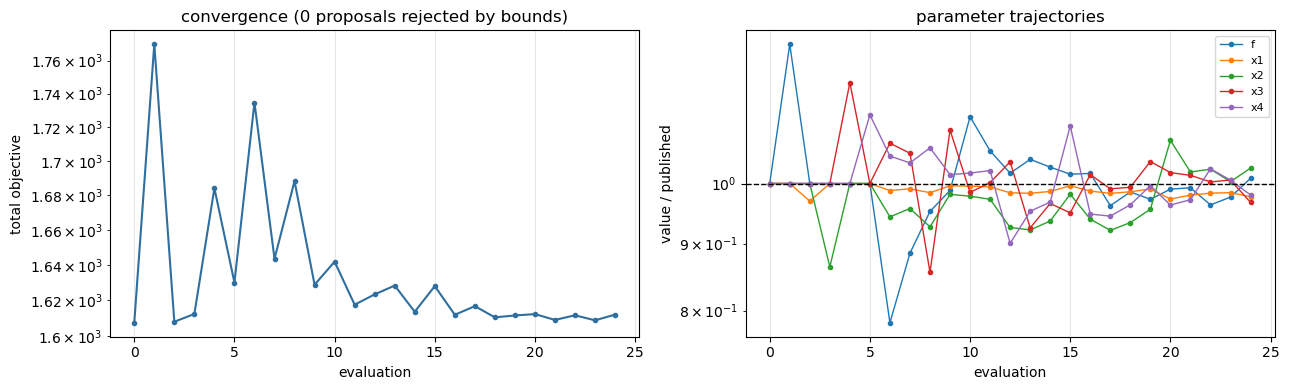

In [16]:
hist = pd.DataFrame(f.history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ok = hist[hist['rejected'].isna()]
axes[0].plot(ok.index, ok['total'], '.-', color='#2f6f9f')
axes[0].set_yscale('log'); axes[0].set_xlabel('evaluation'); axes[0].set_ylabel('total objective')
axes[0].set_title(f'convergence ({len(hist)-len(ok)} proposals rejected by bounds)')
axes[0].grid(alpha=0.3)
for n in FITTED:
    axes[1].plot(ok.index, ok[n]/cfg.PUBLISHED[n], '.-', label=n, lw=1)
axes[1].axhline(1.0, color='k', ls='--', lw=1)
axes[1].set_yscale('log'); axes[1].set_xlabel('evaluation')
axes[1].set_ylabel('value / published'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title('parameter trajectories')
fig.tight_layout(); plt.show()

### Why the refit does not move

The objective starts and ends at the same value. That is the right answer, not a broken
optimizer: the published parameters are already a local minimum. Halving and doubling each
fitted parameter walks uphill in **every** direction tested.

This doubles as a check on the refit machinery. If `to_relative` or the scaling-group
wiring were wrong, perturbing a parameter would not produce a clean bowl around the
published point.

In [17]:
rows = []
for name in FITTED:
    for factor in (0.5, 2.0):
        probe = dict(published); probe[name] = published[name] * factor
        r = mo.evaluate(model, probe, data=data, combine=COMBINE)
        rows.append({'parameter': name, 'factor': factor, 'obj1': r.obj1, 'obj2': r.obj2,
                     'obj3': r.obj3, 'total': r.total,
                     '% vs published': (r.total - ref.total) / ref.total * 100})
sens = pd.DataFrame(rows)
print(f'published total = {ref.total:.2f}; every perturbation below should be worse')
sens.round(3)

published total = 1607.51; every perturbation below should be worse


,parameter,factor,obj1,obj2,obj3,total,% vs published
0,f,0.5,2.001,41.438,30.377,2519.375,56.725
1,f,2.0,1.537,70.319,31.063,3358.155,108.904
2,x1,0.5,2.174,44.382,18.966,1829.496,13.809
3,x1,2.0,1.375,78.971,19.964,2167.405,34.830
4,x2,0.5,1.669,52.486,19.432,1702.576,5.914
5,x2,2.0,1.684,52.751,19.444,1727.434,7.460
6,x3,0.5,2.811,48.336,20.158,2739.060,70.391
7,x3,2.0,2.603,54.898,19.076,2725.979,69.578
8,x4,0.5,2.210,55.119,18.841,2294.537,42.738
9,x4,2.0,2.311,51.108,19.857,2345.003,45.878


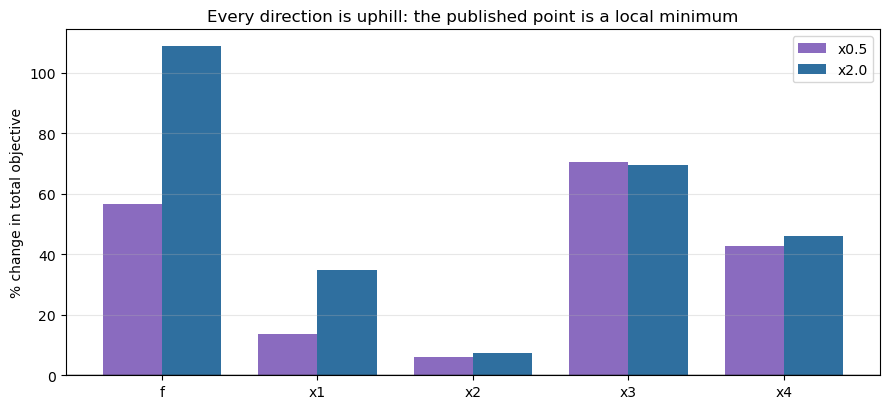

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(FITTED)); w = 0.38
for k, (factor, colour) in enumerate(((0.5, '#8a6bbf'), (2.0, '#2f6f9f'))):
    d = sens[sens.factor == factor].set_index('parameter').loc[FITTED]
    ax.bar(x + (k - 0.5)*w, d['% vs published'], w, color=colour, label=f'x{factor}')
ax.axhline(0, color='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(FITTED)
ax.set_ylabel('% change in total objective'); ax.legend()
ax.set_title('Every direction is uphill: the published point is a local minimum')
ax.grid(axis='y', alpha=0.3); fig.tight_layout(); plt.show()

Worth reading the individual terms, not just the total: `f x2` and `x1 x2` both *improve*
obj1 (1.54 and 1.37 against 1.57) while obj2 blows up to 70 and 79. The product objective
trades the rates away to protect the time course -- section 2b in concrete form.

## 4. Refit vs published

In [19]:
after = mo.evaluate(model, fitted_p, data=data, combine=COMBINE)
pd.DataFrame({
    'term':      ['obj1 (rates)', 'obj2 (time course)', 'obj3 (profile)', 'total'],
    'published': [ref.obj1, ref.obj2, ref.obj3, ref.total],
    'refit':     [after.obj1, after.obj2, after.obj3, after.total],
}).assign(change=lambda d: d['refit']/d['published'])

,term,published,refit,change
0,obj1 (rates),1.573162,1.573162,1.0
1,obj2 (time course),52.573949,52.573949,1.0
2,obj3 (profile),19.436147,19.436147,1.0
3,total,1607.511833,1607.511833,1.0


In [20]:
pd.DataFrame([{'parameter': n, 'published': cfg.PUBLISHED[n], 'refit': fitted_p[n],
               'ratio': fitted_p[n]/cfg.PUBLISHED[n], 'role': cfg.WHAT_EACH_DOES[n]}
              for n in FITTED])

,parameter,published,refit,ratio,role
0,f,132.849936,132.849936,1.0,FabA specificity for the unsaturated branch
1,x1,0.539756,0.539756,1.0,FabF decarboxylation kcat (malonyl-ACP -> acet...
2,x2,0.053673,0.053673,1.0,FabB decarboxylation kcat
3,x3,34.497190,34.497190,1.0,FabF acetyl-CoA binding in the FabH-like route
4,x4,11.150589,11.150589,1.0,FabB acetyl-CoA binding in the FabH-like route


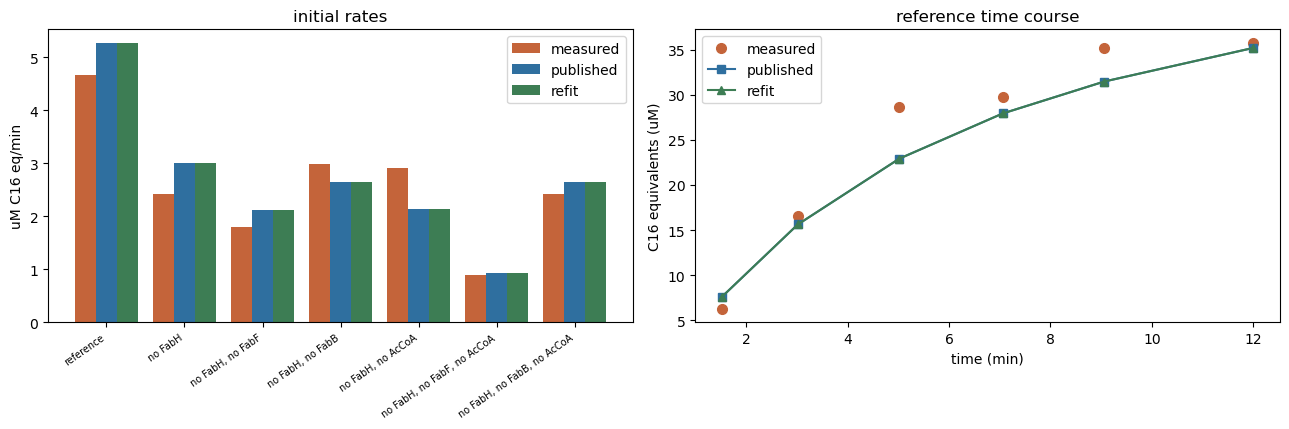

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
x = np.arange(len(rates)); w = 0.27
axes[0].bar(x-w, meas, w, label='measured', color='#c4643a')
axes[0].bar(x,   ref.model_rates/2.5,   w, label='published', color='#2f6f9f')
axes[0].bar(x+w, after.model_rates/2.5, w, label='refit', color='#3d7d54')
axes[0].set_xticks(x); axes[0].set_xticklabels(rates['condition'], rotation=35, ha='right', fontsize=7)
axes[0].set_ylabel('uM C16 eq/min'); axes[0].set_title('initial rates'); axes[0].legend()
axes[1].plot(tc['time_min'], tc['c16_equivalents_uM'], 'o', color='#c4643a', ms=7, label='measured')
axes[1].plot(tc['time_min'], ref.model_timecourse,   's-', color='#2f6f9f', label='published')
axes[1].plot(tc['time_min'], after.model_timecourse, '^-', color='#3d7d54', label='refit')
axes[1].set_xlabel('time (min)'); axes[1].set_ylabel('C16 equivalents (uM)')
axes[1].set_title('reference time course'); axes[1].legend()
fig.tight_layout(); plt.show()

## 4b. Refit to dataset D (run on GPU)

`refit_to_D.py` swaps obj1's target from the fitted rates (A) to the held-out ones (D),
leaving obj2 and obj3 alone, and refits the same five parameters. It runs on the cluster
via `job_files/me1_refit_gpu.sbatch`: batching the seven conditions with `vmap` is
cost-neutral on CPU but real on a GPU, which takes an objective evaluation from ~23 s to
~4 s and makes 250 Nelder-Mead steps a 17-minute job instead of a 90-minute one.

This cell reads whatever result files are present, so it is a no-op until a run has been
pulled back from the cluster.

In [ ]:
import glob
runs = {}
for jf in sorted(glob.glob('refit_to_D_*.json')):
    r = json.load(open(jf))
    runs[r.get('reactions', jf)] = r
if not runs:
    print('no refit_to_D_*.json yet -- run job_files/me1_refit_gpu.sbatch and copy the results here')
else:
    rows = []
    for name, r in runs.items():
        for p in cfg.MATLAB_FITTED:
            rows.append({'reaction set': name, 'parameter': p,
                         'published': r['published'][p], 'refit to D': r['refit_to_D'][p],
                         'ratio': r['refit_to_D'][p] / r['published'][p]})
    display(pd.DataFrame(rows).round(6))
    print()
    display(pd.DataFrame([{'reaction set': n, **r['obj']} for n, r in runs.items()]))

In [ ]:
# Parameter trajectories. A parameter that wanders many orders of magnitude without the
# objective objecting is unidentifiable under this objective -- worth seeing directly,
# because the final value alone looks like a fit result either way.
hists = sorted(glob.glob('refit_to_D_*_history.csv'))
if hists:
    fig, axes = plt.subplots(1, len(hists), figsize=(7.5*len(hists), 4.6), squeeze=False)
    for ax, hf in zip(axes[0], hists):
        h = pd.read_csv(hf); ok = h[h['rejected'].isna()]
        for p in cfg.MATLAB_FITTED:
            ax.plot(ok.index, ok[p] / cfg.PUBLISHED[p], '.-', lw=1, ms=3, label=p)
        ax.axhline(1.0, color='k', ls='--', lw=1)
        ax.set_yscale('log'); ax.set_xlabel('evaluation'); ax.set_ylabel('value / published')
        ax.set_title(hf.replace('refit_to_D_', '').replace('_history.csv', ''), fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.suptitle('Refit to D: parameter trajectories (flat + wandering = unidentifiable)')
    fig.tight_layout(); plt.show()
else:
    print('no history files yet')

In [ ]:
# The four-dataset figures the refit script writes alongside each run.
from IPython.display import Image, display as disp
pngs = sorted(glob.glob('refit_to_D_*.png'))
for p in pngs:
    print(p); disp(Image(filename=p))
if not pngs:
    print('no refit_to_D_*.png yet')

## 5. Notes

**To fit a different subset.** Change `FITTED`. Any of the 18 names works; the bounds in
`me1_config` apply automatically.

**To add a condition.** Append to `cfg.RATE_CONDITIONS` and add a matching row to
`data/initial_rates.csv`. Nothing else needs touching -- the MATLAB required a new
`enz_conc_*` vector, a new `Solver_init` call and a new literal in `rate_exp`.

**To check what a p_vec does to the chemistry.** `model.rate_constants(p)` returns the
effective value of every rate constant. `data/parameter_crosswalk.csv` maps each MATLAB
parameter name and index to the YAML key, reaction, and scaling group.

**Solver tolerances** are `me1_config.RTOL/ATOL`. The MATLAB used `ode15s` at RelTol 1e-6;
looser tolerances make evaluations faster and the objective slightly different.

